# VQ-VAE & GPT-Prior — training curves


In [25]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="white")

DPI = 300
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "legend.fontsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "figure.titlesize": 20,
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
})

BETAS = [0.5, 1.0, 1.5]
CODEBOOK_SIZES = [128, 256, 512]

VQVAE_ROOT = Path("..").resolve()
VQVAE_LOG_DIR = VQVAE_ROOT / "training_logs" / "vqvae"
GPT_LOG_DIR = VQVAE_ROOT / "training_logs" / "gpt_prior"

VQVAE_LOSS_COLUMNS = [
    "train_recon", "train_vq", "train_total",
    "val_recon", "val_vq", "val_total",
]
GPT_CE_COLUMNS = ["train_ce", "val_ce"]

vqvae_logs = {}
for csv_path in sorted(VQVAE_LOG_DIR.glob("vqvae_*_train_log.csv")):
    parts = csv_path.stem.split("_")
    beta, k = float(parts[1]), int(parts[2])
    df = pd.read_csv(csv_path)
    df["val_vq"] = df["val_total"] - df["val_recon"]
    df["codebook_util_pct"] = df["codebook_util"] * 100
    vqvae_logs[(beta, k)] = df


def _longest_contiguous_epochs(df, name="log"):
    df = df.sort_values("epoch").reset_index(drop=True)
    if df["epoch"].diff().fillna(1).eq(1).all():
        return df
    best_start, best_len = 0, 1
    start, run_len = 0, 1
    for i in range(1, len(df)):
        if df.loc[i, "epoch"] == df.loc[i - 1, "epoch"] + 1:
            run_len += 1
        else:
            if run_len > best_len:
                best_start, best_len = start, run_len
            start, run_len = i, 1
    if run_len > best_len:
        best_start, best_len = start, run_len
    cleaned = df.iloc[best_start : best_start + best_len].reset_index(drop=True)
    print(
        f"  cleaned {name}: {len(df)} rows -> {len(cleaned)} "
        f"(epochs {int(cleaned['epoch'].iloc[0])}-{int(cleaned['epoch'].iloc[-1])})"
    )
    return cleaned


gpt_logs = {}
for csv_path in sorted(GPT_LOG_DIR.glob("gpt_*_train_log.csv")):
    parts = csv_path.stem.split("_")
    beta, k = float(parts[1]), int(parts[2])
    df = pd.read_csv(csv_path)
    if not df["epoch"].diff().fillna(1).eq(1).all() or df["epoch"].duplicated().any():
        df = _longest_contiguous_epochs(df, csv_path.name)
    gpt_logs[(beta, k)] = df

print(f"VQ-VAE: {len(vqvae_logs)} runs — {VQVAE_LOG_DIR}")
print(f"GPT-Prior: {len(gpt_logs)} runs — {GPT_LOG_DIR}")


def _style_axes(ax, r, c, beta, k, ylabel):
    if r == 0:
        ax.set_title(f"K = {k}")
    if c == 0:
        ax.set_ylabel(f"beta = {beta}\n{ylabel}")
    ax.tick_params(axis="both", which="major", labelsize=15)
    ax.grid(True, alpha=0.3)


def _mark_best_val_epoch(ax, df, val_col):
    idx = df[val_col].idxmin()
    best_ep = int(df.loc[idx, "epoch"])
    best_val = float(df.loc[idx, val_col])
    ax.axvline(best_ep, color="#d62728", linestyle=":", linewidth=2.2, alpha=0.9, zorder=10)
    ax.annotate(
        f"best val: ep {best_ep}\n{best_val:.4g}",
        xy=(best_ep, 0.94),
        xycoords=("data", "axes fraction"),
        fontsize=12,
        color="#d62728",
        fontweight="bold",
        ha="center",
        va="top",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#d62728", alpha=0.9),
    )

VQ-VAE: 9 runs — /Users/katebohan/Desktop/DL-3-Generative-Models/vq_vae_cats/training_logs/vqvae
GPT-Prior: 9 runs — /Users/katebohan/Desktop/DL-3-Generative-Models/vq_vae_cats/training_logs/gpt_prior


## VQ-VAE losses (log scale)


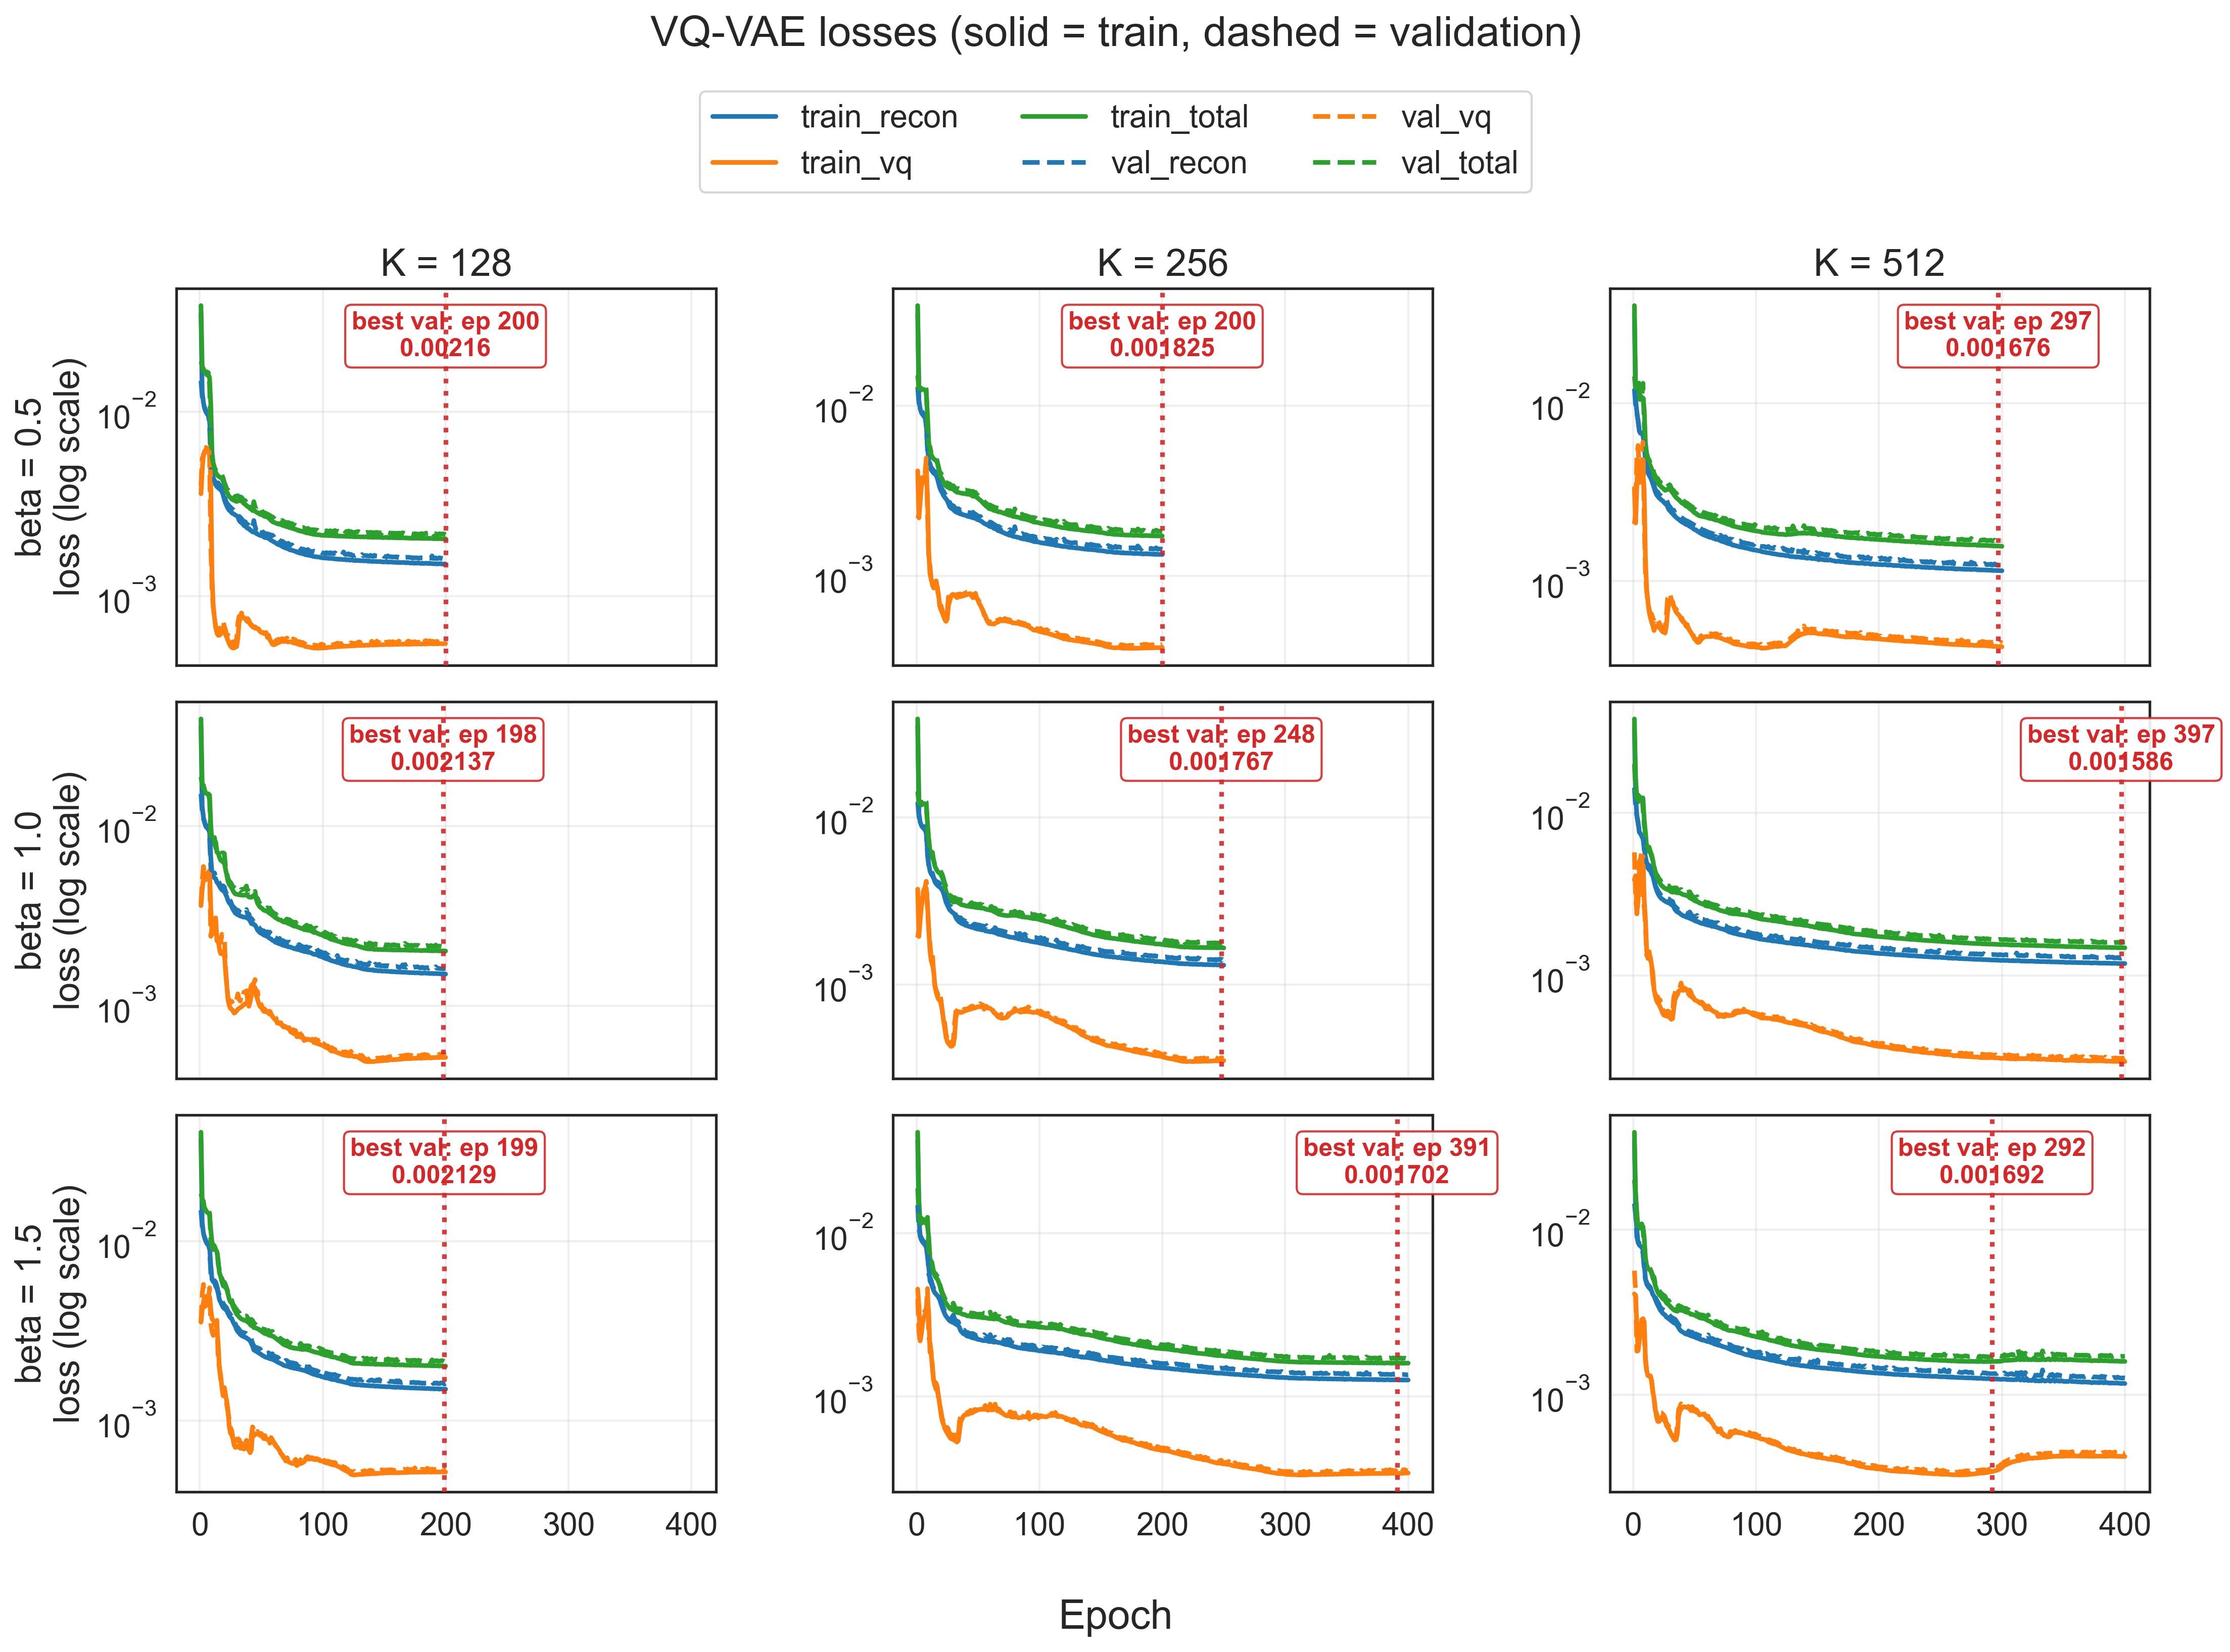

In [29]:
def plot_loss_grid():
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, dpi=DPI)
    colors = {
        "train_recon": "#1f77b4", "train_vq": "#ff7f0e", "train_total": "#2ca02c",
        "val_recon": "#1f77b4", "val_vq": "#ff7f0e", "val_total": "#2ca02c",
    }
    linestyles = {
        "train_recon": "-", "train_vq": "-", "train_total": "-",
        "val_recon": "--", "val_vq": "--", "val_total": "--",
    }
    for r, beta in enumerate(BETAS):
        for c, k in enumerate(CODEBOOK_SIZES):
            ax = axes[r, c]
            df = vqvae_logs[(beta, k)]
            for col in VQVAE_LOSS_COLUMNS:
                ax.plot(
                    df["epoch"], df[col],
                    label=col, color=colors[col],
                    linestyle=linestyles[col], linewidth=2.2,
                )
            ax.set_yscale("log")
            _mark_best_val_epoch(ax, df, "val_total")
            _style_axes(ax, r, c, beta, k, "loss (log scale)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04))
    fig.supxlabel("Epoch")
    fig.suptitle("VQ-VAE losses (solid = train, dashed = validation)", y=1.08)
    plt.tight_layout()
    plt.show()

plot_loss_grid()

## VQ-VAE codebook utilization (%)


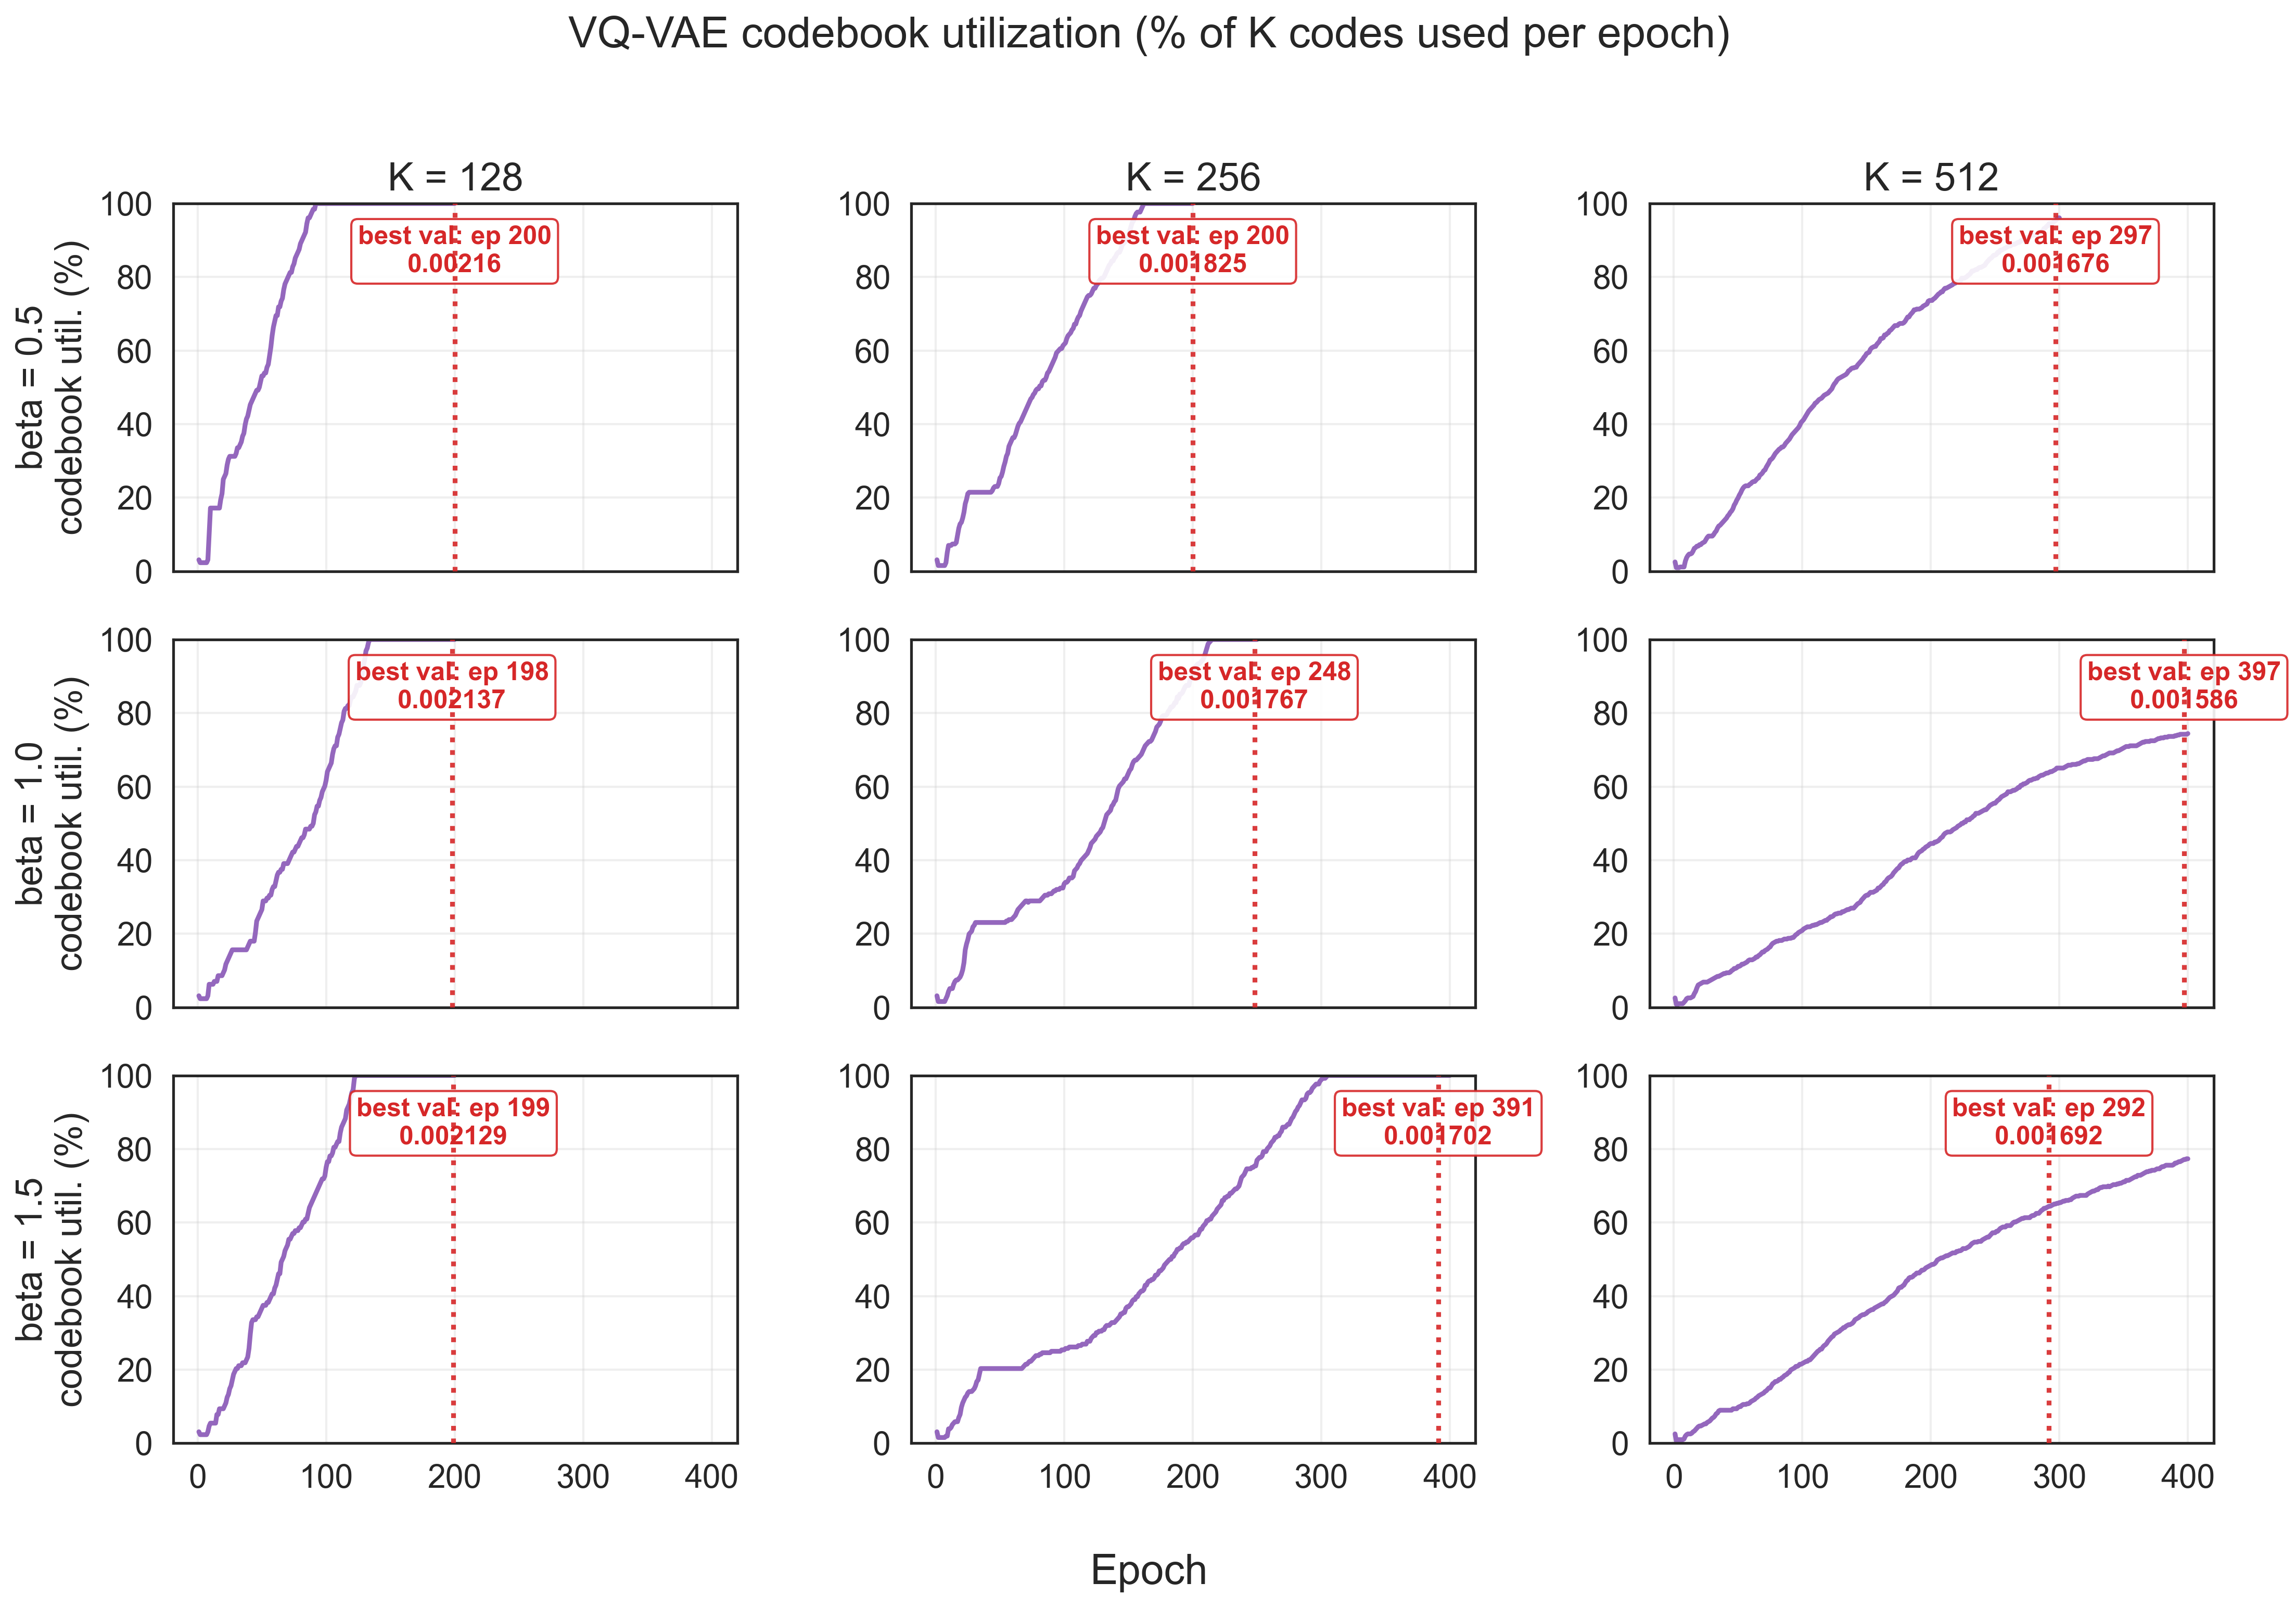

In [30]:
def plot_codebook_util_grid():
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, dpi=DPI)
    for r, beta in enumerate(BETAS):
        for c, k in enumerate(CODEBOOK_SIZES):
            ax = axes[r, c]
            df = vqvae_logs[(beta, k)]
            ax.plot(df["epoch"], df["codebook_util_pct"], color="#9467bd", linewidth=2.2)
            ax.set_ylim(0, 100)
            _mark_best_val_epoch(ax, df, "val_total")
            _style_axes(ax, r, c, beta, k, "codebook util. (%)")
    fig.supxlabel("Epoch")
    fig.suptitle("VQ-VAE codebook utilization (% of K codes used per epoch)", y=1.02)
    plt.tight_layout()
    plt.show()

plot_codebook_util_grid()

## GPT-Prior cross-entropy (log scale)


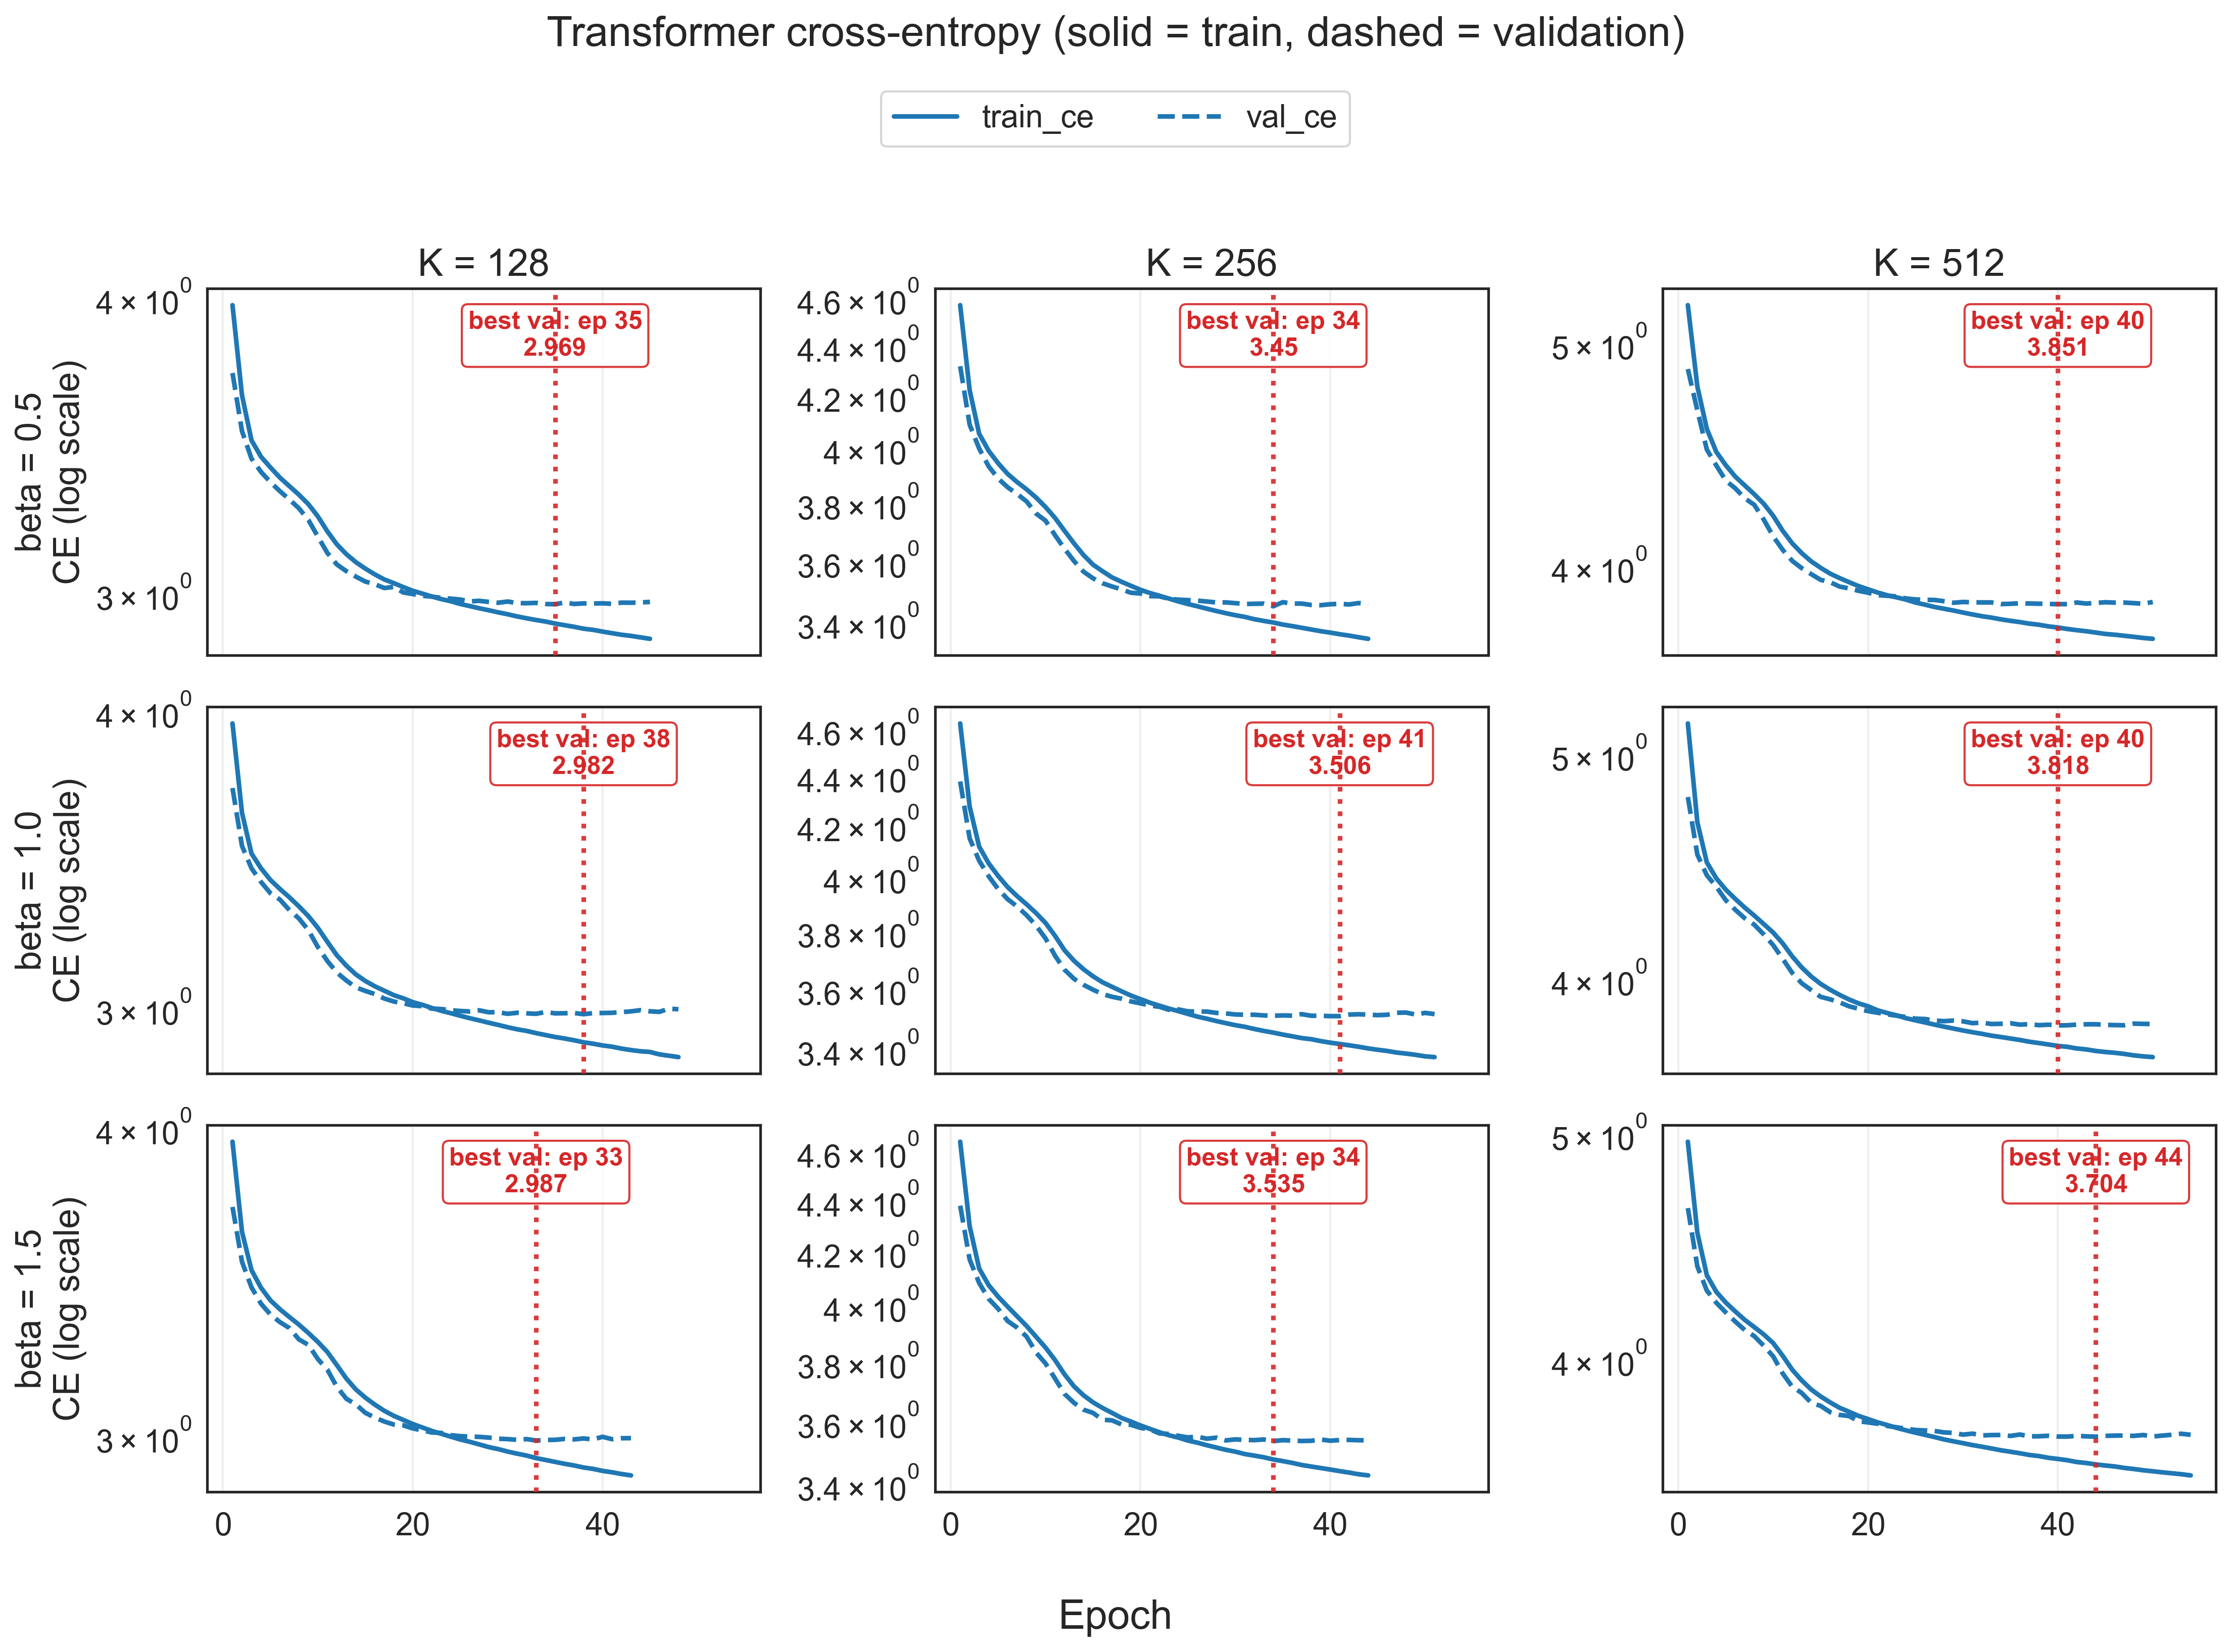

In [32]:
def plot_gpt_ce_grid():
    fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, dpi=DPI)
    colors = {"train_ce": "#1f77b4", "val_ce": "#1f77b4"}
    linestyles = {"train_ce": "-", "val_ce": "--"}
    for r, beta in enumerate(BETAS):
        for c, k in enumerate(CODEBOOK_SIZES):
            ax = axes[r, c]
            df = gpt_logs[(beta, k)]
            for col in GPT_CE_COLUMNS:
                ax.plot(
                    df["epoch"], df[col],
                    label=col, color=colors[col],
                    linestyle=linestyles[col], linewidth=2.2,
                )
            ax.set_yscale("log")
            _mark_best_val_epoch(ax, df, "val_ce")
            _style_axes(ax, r, c, beta, k, "CE (log scale)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
    fig.supxlabel("Epoch")
    fig.suptitle("Transformer cross-entropy (solid = train, dashed = validation)", y=1.08)
    plt.tight_layout()
    plt.show()

plot_gpt_ce_grid()

## FID (GPT sampling, tau = 0.9)


In [ ]:
TAU = 0.9
fid_path = VQVAE_ROOT / "gpt_outputs" / f"fid_results_{TAU}.csv"
if not fid_path.exists():
    print(f"Missing {fid_path}")
else:
    fid_df = pd.read_csv(fid_path)
    fid_pivot = (
        fid_df.pivot(index="beta", columns="K", values="FID")
        .reindex(index=BETAS, columns=CODEBOOK_SIZES)
    )
    print(f"FID per configuration (sampling temperature tau = {TAU})\n")
    display(fid_pivot.round(2))

    fig, ax = plt.subplots(figsize=(5.5, 5), dpi=DPI)
    sns.heatmap(
        fid_pivot,
        annot=True,
        fmt=".1f",
        cmap="viridis_r",
        ax=ax,
        annot_kws={"size": 17},
        linewidths=0.5,
        linecolor="white",
    )
    ax.set_title(f"FID (tau = {TAU})", fontsize=15)
    ax.set_xlabel("codebook size K", fontsize=14)
    ax.set_ylabel("commitment beta", fontsize=14)
    plt.tight_layout()
    plt.show()